# 04_205 · Fine-tuning reanudable de Qwen con cuatro daños

> **Espacio reservado para la sesión iniciada como `04_7`.** Mientras ese kernel siga entrenando, no ejecute este cuaderno en paralelo. Los checkpoints y resultados externos son compartidos.

Este cuaderno entrena **solamente Qwen3-0.6B-Base con LoRA**. Las cuatro salidas operativas son `RACISMO_DISCRIMINACION`, `ACOSO_GENERO_IDENTIDAD`, `ACOSO_AMENAZA` y `CONTENIDO_SEXUAL`. `ACOSO_AMENAZA` es la unión de las antiguas `ACOSO_PERSONAL` y `AMENAZA_DIRECTA`; `SEGURO` se deriva cuando ninguna salida supera su umbral.

Las etiquetas finas y los flags transversales se usan sólo como supervisión auxiliar multitararea. No son variables de entrada, no agregan categorías operativas y las etiquetas finas ausentes quedan enmascaradas. El cuaderno guarda resultados por época y checkpoints completos reanudables durante cada época.

El arranque funciona tanto localmente como en Colab. En local recupera el checkpoint compartido que haya dejado `04_7` o este mismo cuaderno; en Colab usa la instantánea verificada de ese checkpoint sincronizada en Google Drive. `run_finetuning(..., resume=True, force_restart=False)` detecta y reanuda ese estado automáticamente.

In [1]:
from pathlib import Path
from importlib.util import find_spec
import json, os, shutil, subprocess, sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

REPO_URL = 'https://github.com/lkoc/Trabajo_PLN-MIA-Grupo4.git'
GIT_COMMIT = 'ce33b5efd797eef0809e9ff8694c90220cd81e9d'
PROJECT_NAME, DRIVE_BUNDLE_NAME, NEEDS_PEFT = 'Trabajo_PLN-MIA-Grupo4', 'PLN_colab_04_artifacts', True

def _bootstrap_04_20x():
    in_colab = find_spec('google.colab') is not None
    if not in_colab:
        start = Path.cwd().resolve()
        root = next((p for p in (start, *start.parents) if (p / 'scripts_auxiliares').is_dir()), None)
        if root is None: raise FileNotFoundError('No se encontró la raíz local del proyecto.')
        return root, False, root, 'working-tree-local'
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    artifacts = Path('/content/drive/MyDrive') / DRIVE_BUNDLE_NAME
    manifest_path = artifacts / 'MANIFIESTO_ARTEFACTOS_04_20X.json'
    if not manifest_path.is_file(): raise FileNotFoundError('Falta el bundle de Drive; ejecute sincronizar_04_20x_google_drive.ps1 en Windows.')
    manifest = json.loads(manifest_path.read_text(encoding='utf-8-sig'))
    missing = [r['path'] for r in manifest['files'] if not (artifacts / r['path']).is_file()]
    if missing: raise FileNotFoundError('Bundle incompleto en Drive:\n' + '\n'.join(missing))
    root = Path('/content') / PROJECT_NAME
    if not (root / '.git').is_dir():
        if root.exists(): raise RuntimeError(f'Ruta no administrada ya existente: {root}')
        subprocess.run(['git', 'clone', '--filter=blob:none', '--no-checkout', REPO_URL, str(root)], check=True)
    current = subprocess.check_output(['git', '-C', str(root), 'rev-parse', 'HEAD'], text=True).strip()
    if current != GIT_COMMIT:
        subprocess.run(['git', '-C', str(root), 'fetch', '--depth', '1', 'origin', GIT_COMMIT], check=True)
    subprocess.run(['git', '-C', str(root), 'sparse-checkout', 'set', 'scripts_auxiliares'], check=True)
    subprocess.run(['git', '-C', str(root), 'checkout', '--detach', GIT_COMMIT], check=True)
    for name in ('datos', 'modelos', 'resultados'):
        local, target = root / name, artifacts / name
        target.mkdir(parents=True, exist_ok=True)
        if local.is_symlink() and local.resolve() == target.resolve(): continue
        if local.is_symlink(): local.unlink()
        elif local.exists(): raise RuntimeError(f'Ruta de artefactos no administrada: {local}')
        local.symlink_to(target, target_is_directory=True)
    return root, True, artifacts, GIT_COMMIT

ROOT, IN_COLAB, ARTIFACT_ROOT, CODE_VERSION = _bootstrap_04_20x()
if IN_COLAB:
    packages = {'transformers': 'transformers>=4.51,<6', 'sklearn': 'scikit-learn>=1.4', 'peft': 'peft>=0.15,<1'}
    missing_packages = [p for m, p in packages.items() if find_spec(m) is None]
    if missing_packages: subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *missing_packages], check=True)
os.environ['PLN_PROJECT_ROOT'], os.environ['PLN_ARTIFACT_ROOT'] = str(ROOT), str(ARTIFACT_ROOT)
os.chdir(ROOT)
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))

from scripts_auxiliares import entrenar_qwen_acoso_amenaza as qwen4

print('Entorno:', 'Google Colab híbrido' if IN_COLAB else 'local')
print('Código:', ROOT, CODE_VERSION)
print('Artefactos persistentes:', ARTIFACT_ROOT)
print('Modelo:', qwen4.MODEL_SPEC.model_id)
print('Objetivos primarios:', qwen4.TARGET_LABELS)
print('SEGURO derivada:', True)
print('Dispositivo disponible:', qwen4.device())
print('Checkpoint recuperable (04_7/04_205):', qwen4.resume_status())

Proyecto: D:\trabajo_PLN\Trabajo_PLN-MIA-Grupo4
Modelo: Qwen/Qwen3-0.6B-Base
Objetivos primarios: ['RACISMO_DISCRIMINACION', 'ACOSO_GENERO_IDENTIDAD', 'ACOSO_AMENAZA', 'CONTENIDO_SEXUAL']
SEGURO derivada: True
Dispositivo disponible: cpu


## 1. Dataset congelado, unión de etiquetas y auditoría auxiliar

Se reutilizan exactamente el dataset 4:1 y los splits `train/validation/test` creados por `04_2`. Primero se submuestreó `SEGURO` sin retirar daños y después se particionó; este cuaderno no vuelve a muestrear ni modifica los splits. La unión se calcula fila por fila como `max(ACOSO_PERSONAL, AMENAZA_DIRECTA)`.

In [2]:
frames, dataset_audit = qwen4.load_frames()
display(qwen4.dataset_summary(dataset_audit))

coverage = pd.DataFrame(dataset_audit['auxiliary_supervision']['split_coverage']).T
display(coverage[['fine_rows_available', 'fine_rows_masked', 'fine_coverage', 'flag_rows_available']])

print('SHA-256 dataset:', dataset_audit['dataset_sha256'])
print('Fingerprint de entrenamiento:', dataset_audit['training_fingerprint_sha256'])
print('Prompt operativo:', dataset_audit['prompt_operational'])

,split,chunks,RACISMO_DISCRIMINACION,ACOSO_GENERO_IDENTIDAD,ACOSO_AMENAZA,CONTENIDO_SEXUAL,ACOSO_AMENAZA_union,solapamiento_acoso_amenaza
0,train,24701,1319,1394,2077,1613,2077,359
1,validation,5324,281,304,488,334,488,72
2,test,5290,256,263,463,335,463,83


,fine_rows_available,fine_rows_masked,fine_coverage,flag_rows_available
train,24029,672,0.972795,24701
validation,5151,173,0.967506,5324
test,5143,147,0.972212,5290


SHA-256 dataset: df2ac01183271e44b6dcfb9cb4850bd6b1ef1cd11d9fc51c881be944670ef20f
Fingerprint de entrenamiento: c438b8e129b5d3f148fb9962a5e38e23d7a96525f4334ab7569f99975087a7fc
Prompt operativo: {'path': '03_1_etiquetado_llm\\prompt_operacional_compacto.md', 'sha256': '52d4fec14ad433d35ec20de5f51a6954aad69dcedd1422059419dcecc2f9e778', 'bytes': 8402, 'role': 'taxonomy provenance only; it is not model input'}


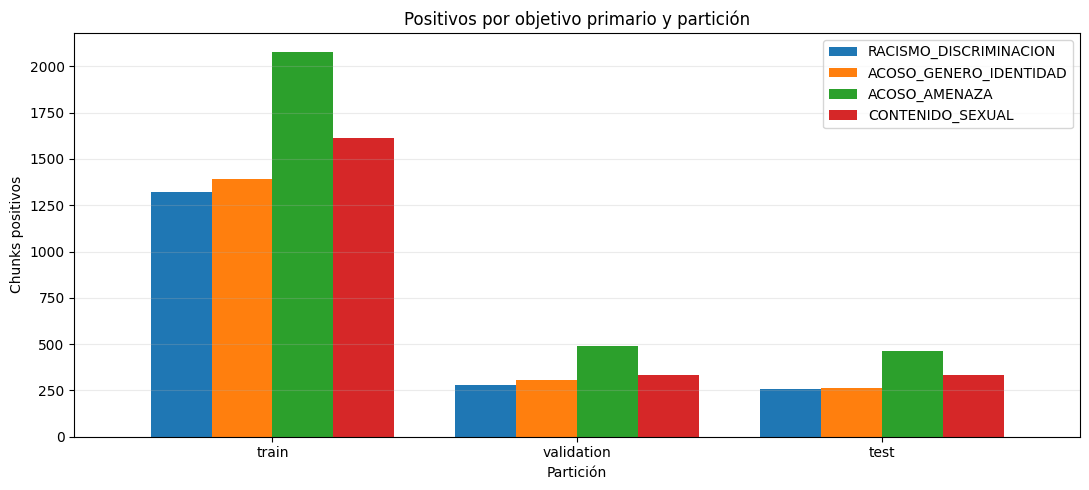

In [3]:
summary = qwen4.dataset_summary(dataset_audit).set_index('split')
ax = summary[qwen4.TARGET_LABELS].plot.bar(figsize=(11, 5), width=0.8)
ax.set_title('Positivos por objetivo primario y partición')
ax.set_ylabel('Chunks positivos')
ax.set_xlabel('Partición')
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Metodología

La tarea primaria es multietiqueta con cuatro logits. Se minimiza entropía cruzada binaria ponderada, y se añaden pérdidas auxiliares de etiquetas finas (peso 0,20) y flags transversales (peso 0,15). La pérdida fina sólo se calcula para los chunks con anotación fina recuperable; una anotación ausente **no** se convierte en una colección de ceros. Las cabezas auxiliares se descartan para la decisión operativa. Este diseño busca que representaciones compartidas aprendan distinciones útiles sin cambiar la taxonomía de producción (Ruder, 2017).

El prompt operativo **no es necesario como entrada del modelo**. Se registra con hash como procedencia de las definiciones usadas al etiquetar. Inyectarlo en cada texto crearía una condición distinta de la inferencia real.

Qwen se ajusta mediante LoRA (Hu et al., 2022). Al final de cada época se selecciona el adaptador con mayor PR-AUC macro de daño en validación. Luego se ajusta calibración sigmoide por etiqueta y los umbrales exclusivamente en validación; test se reserva para la evaluación final (Niculescu-Mizil & Caruana, 2005). No se entrena ningún modelo clásico aquí; si existen sus predicciones congeladas de `04_2`, sólo se leen para una comparación final sobre el mismo test.

## 3. Estado reanudable

Se guarda un checkpoint cada 250 pasos del optimizador, alternando dos directorios para reducir el riesgo de corrupción. Incluye adaptador, optimizador, scheduler, estados aleatorios, época y siguiente lote. También se guardan `best_adapter`, `last_adapter`, logits y métricas por época. Si VS Code, el kernel o la máquina se interrumpen, vuelva a ejecutar desde la primera celda y después la celda de entrenamiento: continuará desde el último checkpoint compatible.

In [4]:
status = qwen4.resume_status()
display(status)

{'status': 'not_started'}

## 4. Entrenamiento de Qwen

Esta es la única celda que entrena un modelo. Déjela terminar. Si se interrumpe, ejecútela otra vez con `resume=True`. Use `force_restart=True` sólo si desea archivar el adaptador existente e iniciar deliberadamente desde cero.

In [ ]:
import importlib
qwen4 = importlib.reload(qwen4)  # evita definiciones antiguas conservadas por el kernel
print('Módulo Qwen recargado:', qwen4.__file__)

training_result = qwen4.run_finetuning(
    frames,
    resume=True,
    force_restart=False,
)
display({
    'status': training_result['status'],
    'epochs_completed': training_result['epochs_completed'],
    'best_epoch': training_result['best_epoch'],
    'best_validation_damage_pr_auc_macro': training_result['best_validation_damage_pr_auc_macro'],
    'adapter': training_result['adapter'],
})

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

c:\Python313\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\USER\.cache\huggingface\hub\models--Qwen--Qwen3-0.6B-Base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/9.68k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

[transformers] Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B-Base
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


qwen3_06b_lora_acoso_amenaza_4 · época 1/2:   0%|          | 0/12351 [00:00<?, ?lote/s]

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


In [ ]:
history_path = qwen4.METRICS_DIR / 'historial.csv'
history = pd.read_csv(history_path)
display(history)
ax = history.plot(x='epoch', y=['damage_pr_auc_macro', 'damage_f1_macro', 'any_damage_recall'], marker='o', figsize=(10, 5))
ax.set_ylim(0, 1)
ax.set_title('Evolución en validación')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 5. Calibración, test y operación selectiva

Esta sección carga `best_adapter`; no vuelve a entrenar. Guarda logits de las 21 salidas internas, logits y probabilidades de las cuatro salidas primarias, calibradores, umbrales, métricas, comparación y el informe Markdown. La decisión sobre moderación autónoma o alerta humana se toma con las puertas declaradas y no sólo con accuracy.

In [ ]:
final_result = qwen4.finalize(frames, force_evaluation=False)
evaluation = final_result['evaluation']
operation = final_result['operation']
comparison = pd.read_csv(qwen4.COMPARISON_PATH)

display(pd.DataFrame([evaluation['metrics']['test']]).drop(columns=['category_recall']))
display(pd.DataFrame.from_dict(evaluation['metrics']['test']['category_recall'], orient='index', columns=['recall_test']))
display(comparison.loc[comparison['split'].eq('test')])
display(operation)

In [ ]:
figure_path = qwen4.FIGURES_DIR / 'comparacion_y_calibracion.png'
display(Markdown(
    f'**Informe reproducible:** `{qwen4.REPORT_PATH.relative_to(ROOT)}`  \n'
    f'**Resultados:** `{(qwen4.METRICS_DIR / "resultado_final.json").relative_to(ROOT)}`  \n'
    f'**Figura:** `{figure_path.relative_to(ROOT)}`  \n'
    f'**Adaptador elegido:** `{qwen4.MODEL_DIR / "best_adapter"}`'
))
display(Image(filename=str(figure_path)))

## Referencias (APA 7)

Hu, E. J., Shen, Y., Wallis, P., Allen-Zhu, Z., Li, Y., Wang, S., Wang, L., & Chen, W. (2022). LoRA: Low-rank adaptation of large language models. *International Conference on Learning Representations*. https://openreview.net/forum?id=nZeVKeeFYf9

Niculescu-Mizil, A., & Caruana, R. (2005). Predicting good probabilities with supervised learning. In *Proceedings of the 22nd International Conference on Machine Learning* (pp. 625–632). ACM. https://doi.org/10.1145/1102351.1102430

Qwen Team. (2025). Qwen3 technical report. *arXiv*. https://doi.org/10.48550/arXiv.2505.09388

Ruder, S. (2017). An overview of multi-task learning in deep neural networks. *arXiv*. https://doi.org/10.48550/arXiv.1706.05098